# Lab: Multi-Class Classification with scikit-learn

In the [theory notes](./05_multi-class_classification_theory.md), we learned *what* multi-class classification is and the three main strategies for solving it: **Softmax Regression**, **One-vs-Rest (OvR)**, and **One-vs-One (OvO)**. In the [implementation file](./06_multi-class_classification_implementation.py), we built all three from scratch.

**Now it's time to see how the real world does it.** In practice, scikit-learn handles all of this with just a few parameter changes. In this lab, we will learn how to:

1.  Load and prepare a multi-class dataset.
2.  Build a **Softmax Regression** model using `LogisticRegression`.
3.  Build an **OvR** model using `OneVsRestClassifier`.
4.  Build an **OvO** model using `OneVsOneClassifier`.
5.  Inspect model internals (coefficients, number of sub-classifiers).
6.  Understand predicted probability distributions.
7.  Visualize how each strategy carves up the feature space.

---

## 1. The Dataset

We'll use the classic **Iris** dataset. It contains measurements of 150 iris flowers from three species: *setosa* (0), *versicolor* (1), and *virginica* (2). Each flower has four measurements: sepal length, sepal width, petal length, and petal width.

This is a perfect dataset for multi-class classification because:
- It has **three classes** (not just two).
- The classes are roughly balanced (~50 samples each).
- One class (*setosa*) is linearly separable from the other two, while the other two overlap — giving us a realistic challenge.

Let's start by importing our libraries and loading the data.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier

# Configurations
plt.style.use("fivethirtyeight")
sns.set_theme(style="white", palette="colorblind")
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["figure.dpi"] = 150

In [2]:
# Load the Iris dataset
iris = load_iris()

# Create a clean DataFrame
feature_names = [name.replace(" (cm)", "").replace(" ", "_") for name in iris.feature_names]
iris_df = pd.DataFrame(iris.data, columns=feature_names)
iris_df["species"] = iris.target
iris_df["species_name"] = iris.target_names[iris.target]

print(f"Dataset: {iris_df.shape[0]} samples, {len(feature_names)} features, {len(iris.target_names)} classes")
print(f"Classes: {list(iris.target_names)}")
print(f"Samples per class:")
print(iris_df["species_name"].value_counts().to_string())
print()
iris_df.head()

Dataset: 150 samples, 4 features, 3 classes
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Samples per class:
species_name
setosa        50
versicolor    50
virginica     50



,sepal_length,sepal_width,petal_length,petal_width,species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


---

## 2. Preparing the Data

We'll separate features from the target and apply **feature scaling**. Logistic Regression (and its multi-class extensions) benefit from having features on similar scales because the optimization algorithm (gradient descent) converges faster and more reliably.

> 📌 **Why scale?** The four iris features are measured in centimeters but have different ranges (e.g., petal width ranges from 0.1–2.5, while sepal length ranges from 4.3–7.9). Without scaling, features with larger magnitudes could dominate the model's optimization.

In [3]:
# Separate features and target
X = iris_df[feature_names].values
y = iris_df["species"].values

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Shape of X_scaled: {X_scaled.shape}")
print(f"Shape of y: {y.shape}")
print(f"\nFeature means after scaling (should be ~0): {X_scaled.mean(axis=0).round(2)}")
print(f"Feature stds after scaling (should be ~1):  {X_scaled.std(axis=0).round(2)}")

Shape of X_scaled: (150, 4)
Shape of y: (150,)

Feature means after scaling (should be ~0): [-0. -0. -0. -0.]
Feature stds after scaling (should be ~1):  [1. 1. 1. 1.]


---

## 3. Strategy 1: Softmax Regression (Native Multi-Class)

This is the most direct approach. Scikit-learn's `LogisticRegression` supports multi-class natively via the `multi_class='multinomial'` parameter. Instead of the sigmoid function, it uses the **softmax function** to compute a probability distribution across all three classes simultaneously.

The key parameter is:
- `multi_class='multinomial'` — tells scikit-learn to use Softmax Regression (one model for all classes).
- `solver='lbfgs'` — an efficient optimization algorithm that supports multinomial.
- `max_iter=200` — enough iterations for convergence on this small dataset.

In [4]:
# Build the Softmax Regression model
softmax_model = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=200
)
softmax_model.fit(X_scaled, y)

print("Softmax Regression model trained!")
print(f"Number of classes: {len(softmax_model.classes_)}")
print(f"Classes: {softmax_model.classes_}")

Softmax Regression model trained!
Number of classes: 3
Classes: [0 1 2]


/Users/ibrahimkocyigit/Documents/repos/kocyigit-dsml/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


### 3.1. Inspecting the Model

Softmax Regression learns **one set of coefficients per class**. The coefficient matrix has shape `(n_classes, n_features)` — each row tells us how much each feature contributes to predicting that specific class.

In [5]:
# Display the coefficient matrix
coef_df = pd.DataFrame(
    softmax_model.coef_,
    columns=feature_names,
    index=iris.target_names
)

print("Coefficient matrix (one row per class):")
print(coef_df.round(4).to_string())
print(f"\nIntercepts: {softmax_model.intercept_.round(4)}")

Coefficient matrix (one row per class):
            sepal_length  sepal_width  petal_length  petal_width
setosa           -1.0766       1.1598       -1.9281      -1.8123
versicolor        0.5899      -0.3626       -0.3646      -0.8270
virginica         0.4867      -0.7971        2.2928       2.6393

Intercepts: [-0.2046  2.0746 -1.8699]


#### 📌 Reading the Coefficient Matrix

Each coefficient tells us how strongly a feature "votes" for that class:
- **Large positive** coefficient → that feature pushes the prediction *toward* this class.
- **Large negative** coefficient → that feature pushes the prediction *away* from this class.

For example, if `petal_length` has a large negative coefficient for *setosa* and a large positive coefficient for *virginica*, it means long petals strongly indicate *virginica* and strongly rule out *setosa*.

### 3.2. Predicted Probability Distributions

The key feature of Softmax Regression is that it outputs a **full probability distribution** over all classes. The probabilities always sum to 1.

In [6]:
# Get predicted probabilities for a few samples
sample_indices = [0, 55, 110]  # One from each species
probas = softmax_model.predict_proba(X_scaled[sample_indices])

proba_df = pd.DataFrame(
    probas,
    columns=iris.target_names,
    index=[f"Sample {i} (true: {iris.target_names[y[i]]})" for i in sample_indices]
)

print("Predicted probability distributions:")
print(proba_df.round(4).to_string())
print(f"\nRow sums (should be 1.0): {probas.sum(axis=1).round(4)}")

Predicted probability distributions:
                              setosa  versicolor  virginica
Sample 0 (true: setosa)       0.9847      0.0153     0.0000
Sample 55 (true: versicolor)  0.0219      0.8703     0.1077
Sample 110 (true: virginica)  0.0009      0.1807     0.8185

Row sums (should be 1.0): [1. 1. 1.]


Notice how each row is a complete probability distribution. The model is very confident about *setosa* (essentially 100%), reasonably confident about the other two, but there's always some uncertainty between *versicolor* and *virginica* — which makes sense, since those two species overlap in feature space.

---

## 4. Strategy 2: One-vs-Rest (OvR)

The OvR strategy trains **one binary classifier per class**. For 3 classes, it trains 3 classifiers:
- Classifier 1: *setosa* vs. [*versicolor* + *virginica*]
- Classifier 2: *versicolor* vs. [*setosa* + *virginica*]
- Classifier 3: *virginica* vs. [*setosa* + *versicolor*]

In scikit-learn, we wrap any binary classifier with `OneVsRestClassifier`:

In [7]:
# Build the One-vs-Rest model
ovr_model = OneVsRestClassifier(
    LogisticRegression(solver="lbfgs", max_iter=200)
)
ovr_model.fit(X_scaled, y)

print("One-vs-Rest model trained!")
print(f"Number of internal binary classifiers: {len(ovr_model.estimators_)}")
print(f"Classes: {ovr_model.classes_}")

One-vs-Rest model trained!
Number of internal binary classifiers: 3
Classes: [0 1 2]


### 4.1. Inspecting the Internal Classifiers

Each internal classifier has its own set of coefficients. Let's see what each one learned:

In [8]:
# Each estimator is a LogisticRegression trained as "this class vs. all others"
for i, estimator in enumerate(ovr_model.estimators_):
    class_name = iris.target_names[i]
    coefs = dict(zip(feature_names, estimator.coef_[0].round(4)))
    print(f"Classifier for '{class_name}' vs. rest:")
    for feat, coef in coefs.items():
        print(f"  {feat:15s}: {coef:+.4f}")
    print()

Classifier for 'setosa' vs. rest:
  sepal_length   : -1.0560
  sepal_width    : +1.2260
  petal_length   : -1.7648
  petal_width    : -1.6292

Classifier for 'versicolor' vs. rest:
  sepal_length   : +0.1360
  sepal_width    : -1.2744
  petal_length   : +0.7971
  petal_width    : -0.9163

Classifier for 'virginica' vs. rest:
  sepal_length   : +0.1402
  sepal_width    : -0.5146
  petal_length   : +2.4807
  petal_width    : +3.1407



---

## 5. Strategy 3: One-vs-One (OvO)

The OvO strategy trains a binary classifier for **every pair** of classes. For 3 classes, that's $\frac{3 \times 2}{2} = 3$ classifiers:
- Classifier 1: *setosa* vs. *versicolor*
- Classifier 2: *setosa* vs. *virginica*
- Classifier 3: *versicolor* vs. *virginica*

At prediction time, each classifier "votes" for one of its two classes, and the class with the most votes wins.

In [9]:
# Build the One-vs-One model
ovo_model = OneVsOneClassifier(
    LogisticRegression(solver="lbfgs", max_iter=200)
)
ovo_model.fit(X_scaled, y)

n_classifiers = len(ovo_model.estimators_)
n_classes = len(ovo_model.classes_)

print("One-vs-One model trained!")
print(f"Number of classes: {n_classes}")
print(f"Number of internal binary classifiers: {n_classifiers}")
print(f"Formula check: k*(k-1)/2 = {n_classes}*{n_classes-1}/2 = {n_classes*(n_classes-1)//2} ✓")

One-vs-One model trained!
Number of classes: 3
Number of internal binary classifiers: 3
Formula check: k*(k-1)/2 = 3*2/2 = 3 ✓


### 5.1. Inspecting the Internal Classifiers

Let's see what each pair-wise classifier learned:

In [10]:
# The pairings are stored in ovo_model.pairwise_indices_ but we can reconstruct them
from itertools import combinations

pairs = list(combinations(range(n_classes), 2))

for idx, (i, j) in enumerate(pairs):
    estimator = ovo_model.estimators_[idx]
    name_i = iris.target_names[i]
    name_j = iris.target_names[j]
    coefs = dict(zip(feature_names, estimator.coef_[0].round(4)))
    print(f"Classifier: '{name_i}' vs. '{name_j}':")
    for feat, coef in coefs.items():
        print(f"  {feat:15s}: {coef:+.4f}")
    print()

Classifier: 'setosa' vs. 'versicolor':
  sepal_length   : +1.0440
  sepal_width    : -1.2341
  petal_length   : +1.7411
  petal_width    : +1.5912

Classifier: 'setosa' vs. 'virginica':
  sepal_length   : +0.8860
  sepal_width    : -0.7200
  petal_length   : +1.4255
  petal_width    : +1.4596

Classifier: 'versicolor' vs. 'virginica':
  sepal_length   : +0.1396
  sepal_width    : -0.5143
  petal_length   : +2.4812
  petal_width    : +3.1409



> 📌 **Notice the difference:** Each OvO classifier only trains on data from the two relevant classes. This means each classifier sees a simpler problem, but we need more of them. For algorithms that scale poorly with dataset size (like kernelized SVMs), OvO can actually be faster because each sub-problem is smaller.

---

## 6. Making Predictions

All three strategies follow the same scikit-learn API: `.predict()` returns class labels, and `.predict_proba()` (where available) returns probabilities.

In [11]:
# Create a few "new" flowers to classify
new_flowers = pd.DataFrame({
    "sepal_length": [5.0, 6.0, 7.0],
    "sepal_width":  [3.5, 2.8, 3.0],
    "petal_length": [1.4, 4.5, 6.0],
    "petal_width":  [0.2, 1.5, 2.0]
})

# Scale with the SAME scaler (use .transform(), not .fit_transform())
new_flowers_scaled = scaler.transform(new_flowers)

# Predict with all three strategies
for name, model in [("Softmax", softmax_model), ("OvR", ovr_model), ("OvO", ovo_model)]:
    preds = model.predict(new_flowers_scaled)
    pred_names = iris.target_names[preds]
    print(f"{name:8s} predictions: {list(pred_names)}")

Softmax  predictions: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
OvR      predictions: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
OvO      predictions: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


/Users/ibrahimkocyigit/Documents/repos/kocyigit-dsml/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


All three strategies agree on these clear-cut examples. They tend to diverge only on borderline cases near the decision boundaries.

---

## 7. Visualizing Decision Boundaries

To really understand how each strategy divides the feature space, let's visualize the **decision boundaries** using just two features: `petal_length` and `petal_width`. These are the two most discriminative features for Iris classification.

We'll retrain each model on just these two features so we can plot them in 2D.

/Users/ibrahimkocyigit/Documents/repos/kocyigit-dsml/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


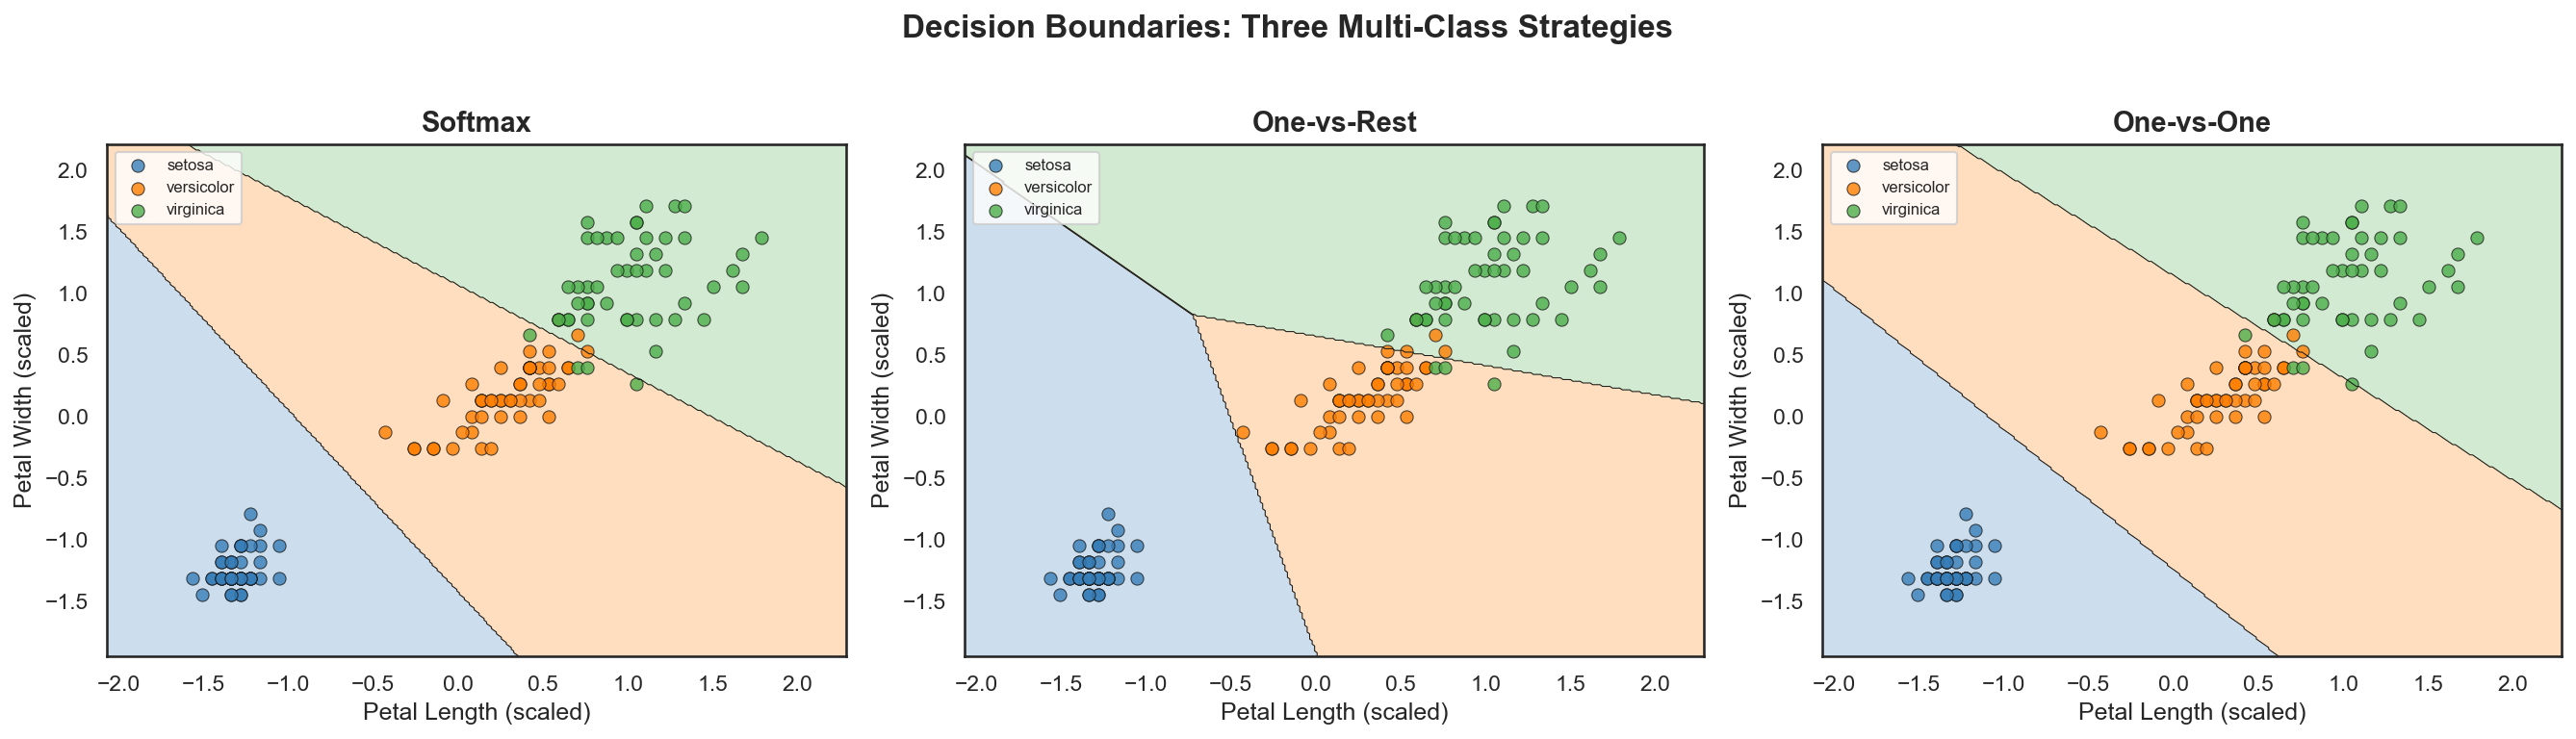

In [12]:
# Use only petal_length and petal_width for visualization
X_2d = iris_df[["petal_length", "petal_width"]].values
scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

# Train all three models on the 2D data
models_2d = {
    "Softmax": LogisticRegression(multi_class="multinomial", solver="lbfgs", max_iter=200),
    "One-vs-Rest": OneVsRestClassifier(LogisticRegression(solver="lbfgs", max_iter=200)),
    "One-vs-One": OneVsOneClassifier(LogisticRegression(solver="lbfgs", max_iter=200)),
}

for model in models_2d.values():
    model.fit(X_2d_scaled, y)

# Create a mesh grid for plotting
x_min, x_max = X_2d_scaled[:, 0].min() - 0.5, X_2d_scaled[:, 0].max() + 0.5
y_min, y_max = X_2d_scaled[:, 1].min() - 0.5, X_2d_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

# Plot decision boundaries
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ["#377eb8", "#ff7f00", "#4daf4a"]

for ax, (name, model) in zip(axes, models_2d.items()):
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, colors=colors, levels=[-0.5, 0.5, 1.5, 2.5])
    ax.contour(xx, yy, Z, colors="k", linewidths=0.5, levels=[0.5, 1.5])

    for cls_idx in range(3):
        mask = y == cls_idx
        ax.scatter(
            X_2d_scaled[mask, 0], X_2d_scaled[mask, 1],
            label=iris.target_names[cls_idx],
            edgecolors="k", linewidths=0.5, s=40, alpha=0.8,
            color=colors[cls_idx]
        )

    ax.set_title(name, fontsize=14, fontweight="bold")
    ax.set_xlabel("Petal Length (scaled)")
    ax.set_ylabel("Petal Width (scaled)")
    ax.legend(loc="upper left", fontsize=8)

fig.suptitle("Decision Boundaries: Three Multi-Class Strategies", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 📌 What to Notice

- **Setosa** (blue) is perfectly separated in all three strategies — it's the "easy" class.
- The interesting differences are in how each strategy draws the boundary between **versicolor** (orange) and **virginica** (green).
- **Softmax** produces a single, smooth set of boundaries since it optimizes all three classes jointly.
- **OvR** can sometimes produce slightly different boundaries because each binary classifier is trained independently.
- **OvO** uses pairwise voting, which can lead to subtly different decisions near the boundary.

For this well-behaved dataset, the three strategies produce very similar results. The differences become more pronounced with more classes, more complex data, or different base classifiers.

---

## 8. Comparing the Strategies at a Glance

Let's create a summary table comparing the three strategies on key structural differences:

In [13]:
# Build a comparison summary
k = len(iris.target_names)

comparison = pd.DataFrame({
    "Strategy": ["Softmax (Multinomial)", "One-vs-Rest (OvR)", "One-vs-One (OvO)"],
    "# Binary Classifiers": ["1 (native multi-class)", f"{k} (one per class)", f"{k*(k-1)//2} (one per pair)"],
    "scikit-learn API": [
        'LogisticRegression(multi_class="multinomial")',
        "OneVsRestClassifier(estimator)",
        "OneVsOneClassifier(estimator)",
    ],
    "Outputs Probabilities?": ["Yes (.predict_proba)", "Yes (.predict_proba)", "No (uses voting)"],
    "Best For": [
        "Default choice for LR",
        "Any binary classifier",
        "Classifiers slow on large data (e.g., SVM)",
    ],
})

print(comparison.to_string(index=False))

             Strategy   # Binary Classifiers                              scikit-learn API Outputs Probabilities?                                   Best For
Softmax (Multinomial) 1 (native multi-class) LogisticRegression(multi_class="multinomial")   Yes (.predict_proba)                      Default choice for LR
    One-vs-Rest (OvR)      3 (one per class)                OneVsRestClassifier(estimator)   Yes (.predict_proba)                      Any binary classifier
     One-vs-One (OvO)       3 (one per pair)                 OneVsOneClassifier(estimator)       No (uses voting) Classifiers slow on large data (e.g., SVM)


---

## Summary

In this lab, we learned how to use scikit-learn to build multi-class classification models using three different strategies. Here's what we covered:

| Step | What We Did | Key scikit-learn API |
|------|-------------|---------------------|
| Load data | Loaded the Iris dataset (3 classes) | `load_iris()` |
| Scale features | Standardized all features | `StandardScaler` |
| Softmax | Trained a native multi-class model | `LogisticRegression(multi_class='multinomial')` |
| OvR | Trained one binary classifier per class | `OneVsRestClassifier(LogisticRegression())` |
| OvO | Trained one classifier per class pair | `OneVsOneClassifier(LogisticRegression())` |
| Inspect | Viewed coefficients and internal classifiers | `.coef_`, `.estimators_` |
| Predict | Made predictions with all three strategies | `.predict()`, `.predict_proba()` |
| Visualize | Plotted 2D decision boundaries | `contourf` |

The key takeaways are:

1.  **Softmax Regression** is the default and simplest choice for `LogisticRegression` — it handles multi-class natively.
2.  **OvR and OvO wrappers** let you use *any* binary classifier for multi-class problems. They're most useful when the base classifier doesn't support multi-class natively (e.g., SVMs).
3.  All three strategies use the same scikit-learn API (`.fit()`, `.predict()`), making them easy to swap in and out.

---

**Next:** [Decision Trees Theory](./08_decision_trees_theory.md)